# Simulating a PTA dataset with ATLAS

Generates simulated pulsar timing residuals containing a known injection, and
writes them back into pulsar objects that downstream analysis notebooks can
load exactly like real data.

**What gets injected**

| Component | Model | Controlled by |
|---|---|---|
| Correlated GW background | power law, fixed gamma = 13/3, Hellings-Downs correlations | `GWB_LOG10_A`, `GWB_NFREQS` |
| Per-pulsar intrinsic red noise | power law | `IRN_PRIOR_LOW/HIGH`, `IRN_NFREQS` |
| White noise | EFAC / EQUAD / ECORR from a JSON dictionary | `WN_DICT_PATH`, `WN_DONOR` |
| Timing model perturbations | offsets in the sampled timing parameters | `TIMING_Z_SCALE`, `TIMING_PARAM_FILTER` |

**Outputs**

- One pickle per pulsar per realization: `{OUT_DIR}/{realization}_{pulsar_index}.pkl`
- `{OUT_DIR}/info.npz` recording every injected value, so recovery can be checked

**How to use this notebook**

Edit the configuration cell only. Everything below it runs top to bottom without
further edits.

## 1. Configuration

Everything you need to change lives in this one cell.

In [1]:
from pathlib import Path

# ---------------------------------------------------------------- paths ----
ATLAS_DIR    = Path('/home/koonima/ATLAS/ATLAS')
PAR_DIR      = Path('/home/koonima/ATLAS/datasets/NG15/par')
TIM_DIR      = Path('/home/koonima/ATLAS/datasets/NG15/tim')
PSRS_PICKLE  = '/home/koonima/ATLAS/datasets/NG15/ATLAS_pulsar'
WN_DICT_PATH = Path('/home/koonima/ATLAS/datasets/NG15/v1p1_wn_dict.json')
OUT_DIR      = Path('/home/koonima/ATLAS/datasets/NG15/SIM')

# ------------------------------------------------------------ selection ----
# Indices into PULSAR_NAMES (defined in section 2). None -> use all of them.
PULSAR_SUBSET = [0, 1]

# ------------------------------------------------------------ injection ----
GWB_NFREQS   = 14          # Fourier bins for the common correlated process
IRN_NFREQS   = 30          # Fourier bins for per-pulsar intrinsic red noise
GWB_LOG10_A  = -13.0       # injected GWB amplitude; gamma is fixed at 13/3

# Intrinsic red-noise prior, drawn from uniformly: [log10_A, gamma]
IRN_PRIOR_LOW  = [-20.0, 1.0]
IRN_PRIOR_HIGH = [-19.0, 1.1]

# GWB prior range (only the amplitude is free; gamma is fixed in the PSD)
GWB_PRIOR_LOW  = [-18.0]
GWB_PRIOR_HIGH = [-11.0]

# --------------------------------------------------------- white noise ----
# Clone one pulsar's WN entries onto every pulsar, so the injected white noise
# is homogeneous across the array. Set WN_DONOR = None to use each pulsar's
# own measured values.
WN_DONOR = None

# ------------------------------------------------------- timing model -----
# Which par-file parameters are perturbed. The default drops JUMPs, DMX bins,
# spin frequencies and eccentricity, which are either degenerate with the noise
# or numerically awkward to perturb.
def TIMING_PARAM_FILTER(p):
    return ('JUMP' not in p.upper()
            and not p.startswith('DMX')
            and not p.startswith('F')
            and 'ECC' not in p)

TIMING_Z_SCALE   = 1    # timing perturbation size, in units of sigma_JUG
TIMING_LOAD_JOBS = 10      # par/tim files loaded in parallel

# ------------------------------------------------------------- output -----
N_REALIZATIONS = 1         # independent GWB realizations
SEED           = 12742     # None -> non-reproducible

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR}")

Output directory: /home/koonima/ATLAS/datasets/NG15/SIM


## 2. Imports and pulsar list

In [2]:
import sys
sys.path.append(str(ATLAS_DIR))
sys.path.append('../')

import glob
import json
import pickle
import random
from functools import partial
import copy

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import trange

import jax
import jax.numpy as jnp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True)

from ATLAS.data import PTA_Data
from ATLAS.psd_functions import *
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS.signals.timing.base import build_multi_psr_timing_model
from ATLAS.nMatrix.base import WhiteCov
from ATLAS import sim
from ATLAS.pulsar import PulsarDataLoader

%load_ext autoreload
%autoreload 2

In [3]:
PULSAR_NAMES = [
    'B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451', 'J0340+4130',
    'J0406+3039', 'J0437-4715', 'J0509+0856', 'J0557+1551', 'J0605+3757',
    'J0610-2100', 'J0613-0200', 'J0636+5128', 'J0645+5158', 'J0709+0458',
    'J0740+6620', 'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001',
    'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330',
    'J1600-3053', 'J1614-2230', 'J1630+3734', 'J1640+2224', 'J1643-1224',
    'J1705-1903', 'J1713+0747', 'J1719-1438', 'J1730-2304', 'J1738+0333',
    'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857',
    'J1802-2124', 'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303',
    'J1903+0327', 'J1909-3744', 'J1910+1256', 'J1911+1347', 'J1918-0642',
    'J1923+2515', 'J1944+0907', 'J1946+3417', 'J2010-1323', 'J2017+0603',
    'J2033+1734', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000',
    'J2229+2643', 'J2234+0611', 'J2234+0944', 'J2302+4442', 'J2317+1439',
    'J2322+2057',
]
print(f"{len(PULSAR_NAMES)} pulsars available")

67 pulsars available


## 3. Locate par and tim files

One par and one tim file per pulsar. Receiver-specific variants (`ao`, `gbt`)
are skipped so each pulsar contributes exactly one dataset.

In [4]:
def find_files(directory, suffix, names, exclude=('ao', 'gbt')):
    """One file per pulsar name, in the order of `names`.

    Raises if any pulsar matches zero or more than one file, which would
    otherwise surface much later as a silent par/tim misalignment.
    """
    all_files = sorted(glob.glob(str(Path(directory) / f'*{suffix}')))
    out = []
    for name in names:
        hits = [f for f in all_files
                if name in f and not any(x in f for x in exclude)]
        if len(hits) != 1:
            raise FileNotFoundError(
                f"{name}: expected exactly one {suffix} file, found {len(hits)}"
                + (f" -> {hits}" if hits else ""))
        out.append(hits[0])
    return out

parfiles = find_files(PAR_DIR, '.par', PULSAR_NAMES)
timfiles = find_files(TIM_DIR, '.tim', PULSAR_NAMES)
print(f"Matched {len(parfiles)} par files and {len(timfiles)} tim files")

Matched 67 par files and 67 tim files


## 4. Load pulsars

In [5]:
paths = sorted(glob.glob(PSRS_PICKLE + '/*.npz'))
psrs = []
for path in paths:
    psrs.append(PulsarDataLoader(**np.load(path)))

if PULSAR_SUBSET is not None:
    psrs     = [psrs[i] for i in PULSAR_SUBSET]
    parfiles = [parfiles[i] for i in PULSAR_SUBSET]
    timfiles = [timfiles[i] for i in PULSAR_SUBSET]

print(f"Loaded {len(psrs)} pulsars")
for p in psrs[:3]:
    tspan_yr = (p.toas.max() - p.toas.min()) / (86400 * 365.25)
    print(f"  {p.name:12s}  {len(p.toas):6d} TOAs   {tspan_yr:5.1f} yr")
print("  ...")

Loaded 2 pulsars
  B1855+09        7758 TOAs    15.6 yr
  B1937+21       23023 TOAs    15.9 yr
  ...


## 5. White-noise dictionary

`make_donor_wn_dict` clones one pulsar's EFAC / EQUAD / ECORR entries onto every
pulsar, giving a homogeneous white-noise level across the array. That is useful
when the point of the simulation is to isolate red-noise recovery.

In [6]:
def make_donor_wn_dict(noise_dict, donor, psr_names, verbose=True):
    """Clone one pulsar's white-noise entries onto every pulsar.

    Only the donor's entries are read; every other pulsar in `noise_dict` is
    ignored. The key structure `{pulsar}_{backend}_{kind}` is preserved, with
    only the pulsar prefix changed.

    Parameters
    ----------
    noise_dict : dict   NANOGrav white-noise JSON dictionary.
    donor      : str    Pulsar whose entries are cloned.
    psr_names  : list   Pulsars to create entries for.

    Returns
    -------
    dict  One set of white-noise entries per pulsar in `psr_names`.
    """
    def _is_wn(key):
        k = key.lower()
        return 'efac' in k or 'equad' in k or 'ecorr' in k

    def _psr_name(key):
        return key.split('_')[0]

    donor_entries = {key[len(_psr_name(key)) + 1:]: val
                     for key, val in noise_dict.items()
                     if _psr_name(key) == donor and _is_wn(key)}

    if not donor_entries:
        raise ValueError(
            f"No white-noise keys found for donor {donor!r}. Available: "
            f"{sorted({_psr_name(k) for k in noise_dict})}")

    out = {f"{psr}_{suf}": val
           for psr in psr_names for suf, val in donor_entries.items()}

    if verbose:
        print(f"Donor {donor}: {len(donor_entries)} white-noise entries")
        for suf, val in sorted(donor_entries.items()):
            print(f"   {suf:<50} = {val}")
        print(f"\nCreated {len(out)} keys for {len(psr_names)} pulsars")
    return out

In [7]:
with open(WN_DICT_PATH, 'r') as fin:
    noise_dict = json.load(fin)

if WN_DONOR is not None:
    noise_dict = make_donor_wn_dict(
        noise_dict, donor=WN_DONOR, psr_names=[p.name for p in psrs])
else:
    print(f"Using each pulsar's own white noise ({len(noise_dict)} keys)")

Using each pulsar's own white noise (697 keys)


## 6. Build the data object

In [8]:
data = PTA_Data(
    psrs,
    fixed_res      = False,
    marg_timing    = False,
    diag_white_cov = False,
    linear_timing  = False,
)
raw_res = jnp.concatenate(data.raw_residuals)
print(f"{data.npsrs} pulsars, {raw_res.shape[0]} TOAs total")

2 pulsars, 30781 TOAs total


## 7. Timing model

`SAMPLE` lists, per pulsar, which par-file parameters get perturbed.
`A1DOT` is renamed to `XDOT` because that is the label JUG uses in its design
matrix, and `fitpars[0]` (the `Offset`) is dropped since it is always
marginalised analytically.

In [9]:
# SAMPLE = [
#     [p.replace('A1DOT', 'XDOT')
#      for p in psrs[pidx].fitpars[1:] if TIMING_PARAM_FILTER(p)]
#     for pidx in range(data.npsrs)
# ]

SAMPLE = [
    [str(p) for p in data.psrs[pidx].fit_param_names if TIMING_PARAM_FILTER(p)]
    for pidx in range(data.npsrs)
]

print(f"Sampling {sum(len(s) for s in SAMPLE)} timing parameters in total")
for name, params in zip(data.psr_names[:3], SAMPLE[:3]):
    print(f"  {name:12s} ({len(params):2d}): {params}")
print("  ...")

Sampling 17 timing parameters in total
  B1855+09     (12): ['A1', 'ELAT', 'ELONG', 'EPS1', 'EPS2', 'M2', 'PB', 'PMELAT', 'PMELONG', 'PX', 'SINI', 'TASC']
  B1937+21     ( 5): ['ELAT', 'ELONG', 'PMELAT', 'PMELONG', 'PX']
  ...


In [10]:
tm_model = build_multi_psr_timing_model(
    parfiles, timfiles, SAMPLE,
    load_how_many_in_parallel = TIMING_LOAD_JOBS,
    data = data,
)
data.add_timing_design_matrix(tm_model.Mmats)

Loading the par and tim files...:   0%|          | 0/2 [00:00<?, ?it/s]

/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 1167 TOA(s) before clock data start (MJD 50155.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 2110 TOA(s) after clock data end (MJD 59079.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 1167 TOA(s) before clock data start (MJD 50155.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 2110 TOA(s) after clock data end (MJD 59079.0); using constant extrapolation
  combined +

[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


### Injected timing-parameter offsets

Each sampled parameter is displaced by `TIMING_Z_SCALE` standard deviations (in
units of JUG's formal uncertainty). The z-vector is built in
`tm_model.sample_list` order, **not** in `SAMPLE` order, because
`setup_timing_model` re-sorts the requested parameters into JUG's design-label
order. Building it in the wrong order silently assigns each offset to the wrong
parameter.

In [11]:
key = jrandom.key(SEED if SEED is not None else random.randint(0, 2**31))

z_parts = []
for pidx in range(data.npsrs):
    key, subkey = jrandom.split(key)
    n_params = len(tm_model.sample_list[pidx])   # canonical (JUG) order
    z_parts.append(TIMING_Z_SCALE * jrandom.normal(subkey, (n_params,)))

z_tm_concat = jnp.concatenate(z_parts)
assert z_tm_concat.shape[0] == tm_model.nparams_total, (
    f"z vector has {z_tm_concat.shape[0]} entries but the model expects "
    f"{tm_model.nparams_total}")
print(f"Timing offset vector: {z_tm_concat.shape[0]} parameters")

Timing offset vector: 17 parameters


In [12]:
# Sanity check: the perturbed timing model produces finite residuals
tm_res = tm_model.residuals(z_tm_concat)
print(f"Residual vector: {tm_res.shape}, "
      f"RMS = {float(jnp.sqrt(jnp.mean(tm_res**2))) * 1e6:.3f} us, "
      f"all finite = {bool(jnp.isfinite(tm_res).all())}")

Residual vector: (30781,), RMS = 6.186 us, all finite = True


## 8. White-noise model

In [13]:
wn_model  = WhiteCov(data=data, stabilize_TNT=True)
theta0_wn = wn_model.params_dict_to_vector(noise_dict)

wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds()
print(f"{theta0_wn.shape[0]} white-noise parameters")
print(f"  first five values: {np.asarray(theta0_wn[:5])}")
print(f"  bounds:            {np.asarray(wn_lower_bound[:5])} "
      f"to {np.asarray(wn_upper_bound[:5])}")

Constructing the white noise cov matrix for B1937+21: 100%|██████████| 2/2 [00:02<00:00,  1.10s/it]

36 white-noise parameters
  first five values: [ 1.11593531  1.00004904  1.04311402  1.11184323 -7.56416433]
  bounds:            [ 0.01  0.01  0.01  0.01 -9.  ] to [10. 10. 10. 10. -5.]


## 9. Red-noise model

Two components sharing one basis: per-pulsar intrinsic red noise (`unc`) and a
Hellings-Downs correlated background (`cor`). The combination string
`"cor+unc->unc"` means both occupy the same Fourier columns, represented by
`unc`'s basis.

In [14]:
sig_unc = Red(
    name             = 'unc',
    psd_function     = partial(powerlaw),
    nfreqs           = IRN_NFREQS,
    lower_bound_psd  = jnp.array(IRN_PRIOR_LOW),
    upper_bound_psd  = jnp.array(IRN_PRIOR_HIGH),
    data             = data,
    use_pulsar_tspan = False,
)

sig_cor = Correlated(
    name            = 'cor',
    psd_function    = partial(powerlaw, gamma=13/3),
    orf_function    = hd_orf,
    nfreqs          = GWB_NFREQS,
    lower_bound_psd = jnp.array(GWB_PRIOR_LOW),
    upper_bound_psd = jnp.array(GWB_PRIOR_HIGH),
    data            = data,
)

sig = SuperSignal(
    signal_list = [sig_unc, sig_cor],
    signal_combination_string = "cor+unc->unc",
    data = data,
)
print(f"T-matrix: {sig.get_Fmat_concat.shape}")
print(f"Signal column slices: {sig.signal_comb_idxs}")

T-matrix: (30781, 60)
Signal column slices: {'cor': slice(0, 28, None), 'unc': slice(0, 60, None)}


### Injected red-noise parameters

Intrinsic red noise is drawn from its prior; the GWB amplitude is then pinned to
`GWB_LOG10_A`. The GWB amplitude is the last entry of the parameter vector.

In [15]:
x0 = sig.model.make_initial_guess(jrandom.key(SEED if SEED is not None else 0))
x0 = x0.at[-1].set(GWB_LOG10_A)

param_names = sig.model.get_param_names()
print(f"{len(x0)} red-noise parameters")
print(f"  injected GWB amplitude: {param_names[-1]} = {float(x0[-1]):.2f}")
print(f"  IRN example:            {param_names[0]} = {float(x0[0]):.2f}, "
      f"{param_names[1]} = {float(x0[1]):.2f}")

5 red-noise parameters
  injected GWB amplitude: gwb_log10_A = -13.00
  IRN example:            B1855+09_irn_log10_A = -19.74, B1855+09_irn_gamma = 1.10


## 10. Simulate

`Sim` draws Fourier coefficients from the injected `phi`, projects them onto the
basis, adds white noise from `theta0_wn`, and adds the timing perturbation.

In [16]:
m_sim = sim.Sim(
    data                = data,
    red_noise_basis     = sig.get_Fmat_concat,   # must NOT include timing columns
    cor_signal          = True,
    uncor_signal        = True,
    parameterized_model = sig.model,
    white_noise_model   = wn_model,
    N_realizations      = N_REALIZATIONS,
    seed                = SEED,
)

sim_res_list = m_sim.sim(
    red_params   = x0,
    white_params = theta0_wn,
    z_tm_concat  = z_tm_concat,
)
print(f"Simulated {len(sim_res_list)} pulsars x {N_REALIZATIONS} realization(s)")

100%|██████████| 2/2 [00:00<00:00,  3.49it/s]

Simulated 2 pulsars x 1 realization(s)


## 11. Inspect the simulated residuals

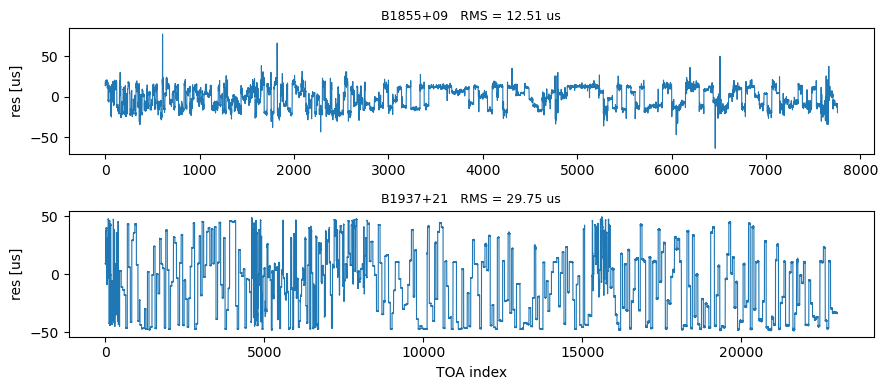

In [17]:
def plot_residuals(sim_res_list, names, realization=0, n_show=6):
    """Residual time series for the first `n_show` pulsars."""
    n_show = min(n_show, len(sim_res_list))
    fig, axes = plt.subplots(n_show, 1, figsize=(9, 2.0 * n_show))
    axes = np.atleast_1d(axes)
    for ax, pidx in zip(axes, range(n_show)):
        res_us = np.asarray(sim_res_list[pidx][realization]) * 1e6
        ax.plot(res_us, lw=0.8)
        ax.set_ylabel('res [us]')
        ax.set_title(f"{names[pidx]}   RMS = {res_us.std():.2f} us", fontsize=9)
    axes[-1].set_xlabel('TOA index')
    fig.tight_layout()
    plt.show()

plot_residuals(sim_res_list, data.psr_names)

In [18]:
# RMS across the whole array: a quick check that nothing blew up
rms = np.array([np.std(np.asarray(sim_res_list[p][0])) * 1e6
                for p in range(data.npsrs)])
print(f"Residual RMS across {data.npsrs} pulsars [us]:")
print(f"  min {rms.min():.3f}   median {np.median(rms):.3f}   max {rms.max():.3f}")
if not np.isfinite(rms).all():
    print("  WARNING: non-finite residuals present")

Residual RMS across 2 pulsars [us]:
  min 12.513   median 21.132   max 29.752


## 12. Write the simulated data (ONLY if using ATLAS data)

Residuals are written back into copies of the pulsar objects, so downstream
notebooks load them exactly as they would load real data.

In [19]:
zero_out_before_injecting = True

In [20]:
for rr in trange(len(sim_res_list[0]), desc='realization'):
    new_psrs = copy.deepcopy(data.psrs)

    for pidx in range(len(sim_res_list)):
        name = data.psr_names[pidx]
        out = OUT_DIR / f"{rr}_{PULSAR_NAMES.index(name)}.npz"
        if zero_out_before_injecting:
            new_psrs[pidx].residuals = sim_res_list[pidx][rr]
        else:
            new_psrs[pidx].residuals += sim_res_list[pidx][rr]

        np.savez_compressed(out, **new_psrs[pidx].__dict__)

realization:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
info_path = OUT_DIR / 'info.npz'
np.savez_compressed(
    info_path,
    z_tm_concat     = np.asarray(z_tm_concat),
    white_noise     = np.asarray(theta0_wn),
    red_noise       = np.asarray(x0),
    red_noise_names = np.array(sig.model.get_param_names()),
    gwb_nfreqs      = GWB_NFREQS,
    non_gwb_nfreqs  = IRN_NFREQS,
    gwb_log10_A     = GWB_LOG10_A,
    pulsar_names    = np.array(data.psr_names),
)
print(f"Injection recorded in {info_path}")
print(f"  keys: {list(np.load(info_path).keys())}")

Injection recorded in /home/koonima/ATLAS/datasets/NG15/SIM/info.npz
  keys: ['z_tm_concat', 'white_noise', 'red_noise', 'red_noise_names', 'gwb_nfreqs', 'non_gwb_nfreqs', 'gwb_log10_A', 'pulsar_names']


## 12. Write the simulated data (ONLY if using pickle files)

Residuals are written back into copies of the pulsar objects, so downstream
notebooks load them exactly as they would load real data.

In [22]:
pickled_psrs_objects = m_sim.write_to_psrs(
    sim_res_list, overwrite=True, load_how_many_in_parallel=1)

100%|██████████| 1/1 [00:00<00:00, 53.60it/s]


In [23]:
for rr in trange(len(pickled_psrs_objects), desc='realization'):
    for pidx in range(m_sim.Npulsars):
        name = data.psr_names[pidx]
        out = OUT_DIR / f"{rr}_{PULSAR_NAMES.index(name)}.pkl"
        with open(out, 'wb') as fout:
            pickle.dump(pickled_psrs_objects[rr][pidx], fout)

print(f"Wrote {len(pickled_psrs_objects) * m_sim.Npulsars} pickles to {OUT_DIR}")

realization:   0%|          | 0/1 [00:00<?, ?it/s]

Wrote 2 pickles to /home/koonima/ATLAS/datasets/NG15/SIM


### Record the injection

Everything needed to check recovery: the injected red-noise parameters, the
white-noise vector, the timing offsets, and the bin counts the models were built
with.

In [24]:
info_path = OUT_DIR / 'info.npz'
np.savez_compressed(
    info_path,
    z_tm_concat     = np.asarray(z_tm_concat),
    white_noise     = np.asarray(theta0_wn),
    red_noise       = np.asarray(x0),
    red_noise_names = np.array(sig.model.get_param_names()),
    gwb_nfreqs      = GWB_NFREQS,
    non_gwb_nfreqs  = IRN_NFREQS,
    gwb_log10_A     = GWB_LOG10_A,
    pulsar_names    = np.array(data.psr_names),
)
print(f"Injection recorded in {info_path}")
print(f"  keys: {list(np.load(info_path).keys())}")

Injection recorded in /home/koonima/ATLAS/datasets/NG15/SIM/info.npz
  keys: ['z_tm_concat', 'white_noise', 'red_noise', 'red_noise_names', 'gwb_nfreqs', 'non_gwb_nfreqs', 'gwb_log10_A', 'pulsar_names']


## 13. Verification

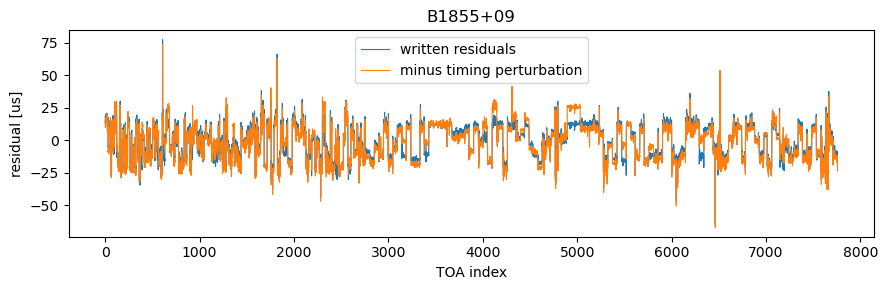

Timing perturbation RMS: 4.4673 us
Stochastic RMS:          13.2270 us


In [25]:
pidx = 0
written    = np.asarray(new_psrs[pidx].residuals)
tm_part    = np.asarray(tm_model.timing_model_residuals_per_pulsar(z_tm_concat)[pidx])
stochastic = written - tm_part

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(written * 1e6,    lw=0.8, label='written residuals')
ax.plot(stochastic * 1e6, lw=0.8, label='minus timing perturbation')
ax.set_xlabel('TOA index')
ax.set_ylabel('residual [us]')
ax.set_title(data.psr_names[pidx])
ax.legend()
fig.tight_layout()
plt.show()

print(f"Timing perturbation RMS: {tm_part.std() * 1e6:.4f} us")
print(f"Stochastic RMS:          {stochastic.std() * 1e6:.4f} us")